### **Polynomial Linear Regression**

`A polynomial is an expression made of numbers and variables raised to whole-number powers, added or subtracted together.`

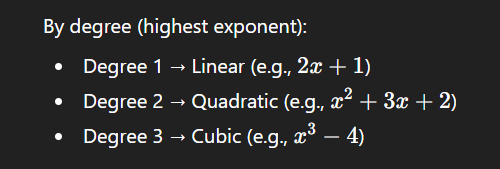

#### **What type of Problem Solved**

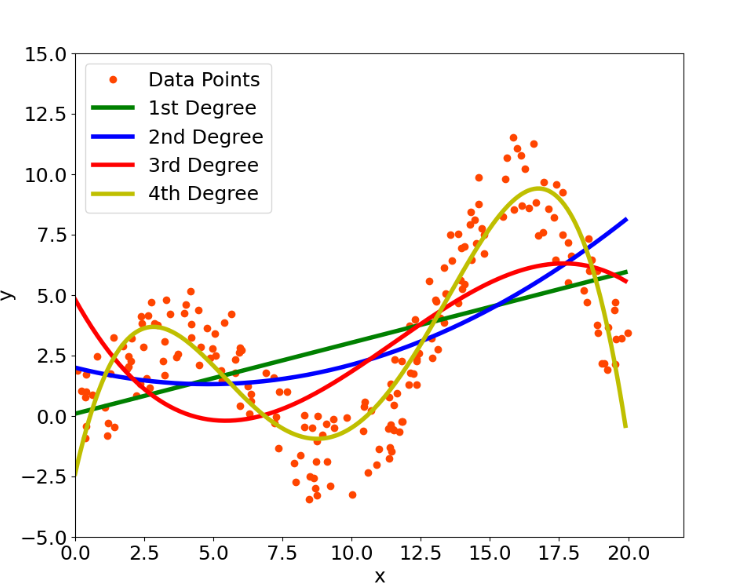

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [11]:
### Creating Own Dataset


X = 6 * np.random.rand(100,1)-3
y = 0.9 * X**2 + 1.5*X + 2 + np.random.randn(100,1)   # ax^2 + bx + c  
# it is a quadratic equation  

In [12]:
X[:15]

array([[ 1.69346321],
       [ 1.736386  ],
       [ 2.66096973],
       [-0.60170462],
       [ 1.24964112],
       [ 2.44792503],
       [ 1.92762957],
       [-1.23573099],
       [ 0.24439262],
       [-1.54572479],
       [ 2.56565671],
       [-0.98444815],
       [-2.43133967],
       [-0.49375017],
       [-1.04335352]])

In [13]:
y[:5]

array([[ 8.1470519 ],
       [ 7.71860089],
       [13.64393819],
       [ 0.97189015],
       [ 6.18444936]])

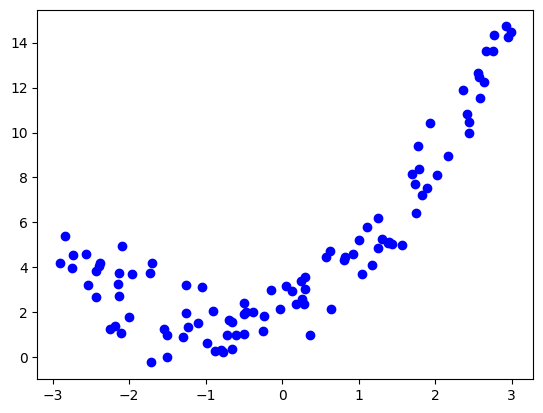

In [15]:
plt.scatter(X,y,color='b')

* This datapoints has not a completely linear Relationship 

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_trian,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

#### 1. `First try Simple Linear Regression ` on Non Linear Data

In [18]:
from sklearn.linear_model import LinearRegression
simple_linear_reg = LinearRegression()

* I am not doing scaling because values are almost in one scale

In [19]:
simple_linear_reg.fit(X_trian,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
from sklearn.metrics import r2_score
score = r2_score(y_test,simple_linear_reg.predict(X_test))

print('Accuracy by Simple Linear Regression: ',score)

Accuracy by Simple Linear Regression:  0.6626253728193823


<Axes: >

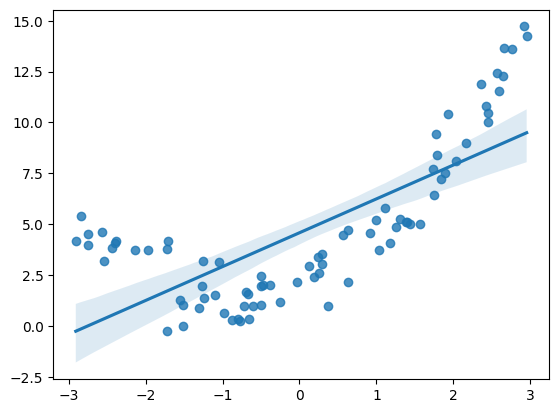

In [22]:
### Lets Visualize this model 
sns.regplot(x=X_trian,y=y_train)

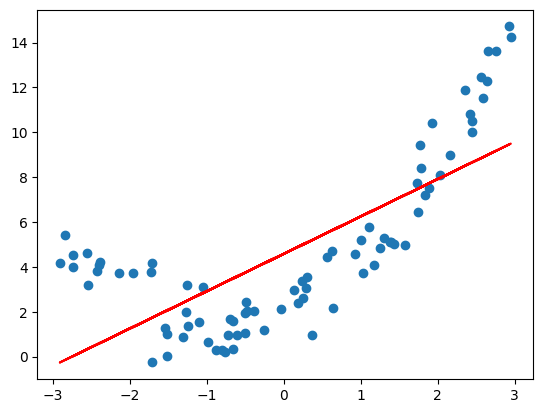

In [ ]:
## another technique to plot
plt.plot(X_trian,simple_linear_reg.predict(X_trian),color='r')
plt.scatter(X_trian,y_train)

### Now we apply **Ploynomial Linear Regression** by increasing Degree

In [26]:
## Lets apply polynommial transformation
from sklearn.preprocessing import PolynomialFeatures

# `Degree = 2`

In [27]:
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_poly = poly.fit_transform(X_trian)
X_test_poly = poly.transform(X_test)


In [29]:
X_train_poly[:10]

array([[ 1.        ,  1.43730687,  2.06585103],
       [ 1.        ,  1.77054006,  3.13481209],
       [ 1.        ,  0.56916682,  0.32395087],
       [ 1.        ,  2.44685148,  5.98708219],
       [ 1.        ,  2.92257686,  8.54145548],
       [ 1.        , -1.51221126,  2.28678288],
       [ 1.        ,  2.16331252,  4.67992104],
       [ 1.        ,  1.74407644,  3.04180261],
       [ 1.        , -1.54572479,  2.38926512],
       [ 1.        , -1.09520343,  1.19947055]])

In [30]:
X_test_poly[:5]

array([[ 1.        ,  0.28761008,  0.08271956],
       [ 1.        , -2.18610202,  4.77904205],
       [ 1.        , -0.14917675,  0.0222537 ],
       [ 1.        , -2.00561414,  4.02248806],
       [ 1.        ,  0.81262739,  0.66036327]])

In [31]:

from sklearn.metrics import r2_score
regression_poly = LinearRegression()
regression_poly.fit(X_train_poly,y_train)
y_pred = regression_poly.predict(X_test_poly)

score = r2_score(y_test,y_pred)

print('Accuracy of Polynomial: ',score)


Accuracy of Polynomial:  0.9322048979157451


In [32]:
## lets check coeficient 
regression_poly.coef_

array([[0.        , 1.51872838, 0.91321016]])

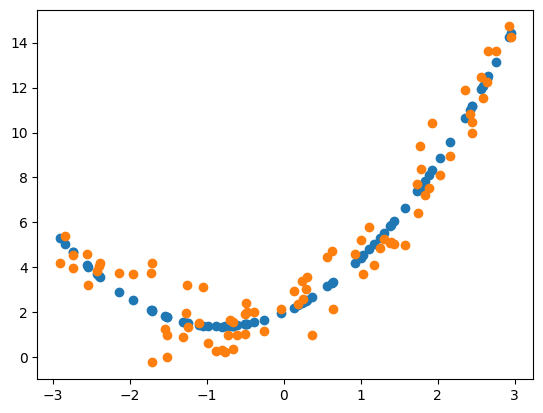

In [34]:
## lets plot
plt.scatter(X_trian,regression_poly.predict(X_train_poly))
plt.scatter(X_trian,y_train)

`Conclusion `
* This show how our model is performing best by using polynomial Regression

# `Degree=3`

In [35]:
poly = PolynomialFeatures(degree=3,include_bias=True)

X_train_poly = poly.fit_transform(X_trian)
X_test_poly = poly.transform(X_test)


In [36]:
## now we should have four feature 
X_train_poly[:5]

array([[ 1.        ,  1.43730687,  2.06585103,  2.96926188],
       [ 1.        ,  1.77054006,  3.13481209,  5.55031037],
       [ 1.        ,  0.56916682,  0.32395087,  0.18438208],
       [ 1.        ,  2.44685148,  5.98708219, 14.64950094],
       [ 1.        ,  2.92257686,  8.54145548, 24.96306011]])

In [37]:
## Again applying the same thing by changing degree to 3

from sklearn.metrics import r2_score
regression_poly = LinearRegression()
regression_poly.fit(X_train_poly,y_train)
y_pred = regression_poly.predict(X_test_poly)

score = r2_score(y_test,y_pred)

print('Accuracy of Polynomial: ',score)


Accuracy of Polynomial:  0.9315751331543723


In [ ]:
## Prediction for new data
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)

X_new_poly[:5]

array([[  1.        ,  -3.        ,   9.        , -27.        ],
       [  1.        ,  -2.96984925,   8.82000455, -26.19408385],
       [  1.        ,  -2.93969849,   8.64182723, -25.40436647],
       [  1.        ,  -2.90954774,   8.46546804, -24.6306834 ],
       [  1.        ,  -2.87939698,   8.290927  , -23.8728702 ]])

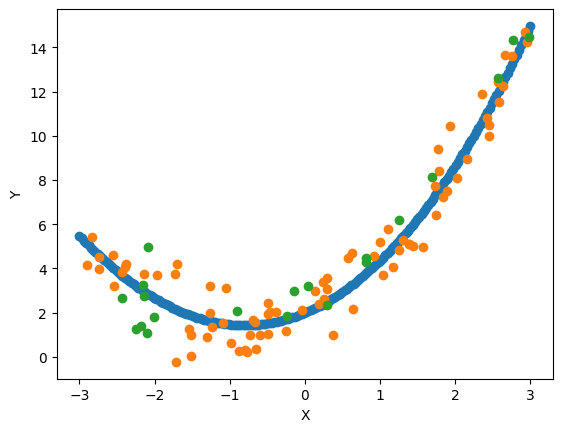

In [46]:
y_new_pred = regression_poly.predict(X_new_poly)

plt.scatter(X_new,y_new_pred,label='Prediction')
plt.scatter(X_trian,y_train,label='Training Points')
plt.scatter(X_test,y_test,label='Testing Points')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()